<a href="https://colab.research.google.com/github/CleliaCaetano/-User-Behavior-Analysis-for-Optimizing-Engagement-on-Social-Media/blob/main/Deep_Learning_Based_Image_Classification_for_Automated_Detection_of_Plant_Diseases_in_Smart_Agriculture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install PyDrive2
!pip install -U -q PyDrive2

# Authenticate and import libraries
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# Authenticate user
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

# Download the file with title 'Fruit-Image-Dataset.zip'
file_list = drive.ListFile({'q': "title='Fruit-Image-Dataset.zip'"}).GetList()

if file_list:
    file_id = file_list[0]['id']
    file = drive.CreateFile({'id': file_id})
    file.GetContentFile('Fruit-Image-Dataset.zip')  # Save with .zip extension
    print("Download complete.")

    # Unzip the downloaded file into folder Fruit-Image-Dataset
    !unzip -o Fruit-Image-Dataset.zip -d Fruit-Image-Dataset

    # List contents to verify
    print("\nContents of Fruit-Image-Dataset:")
    !ls Fruit-Image-Dataset
else:
    print("File not found.")

Streaming output truncated to the last 5000 lines.
  inflating: Fruit-Image-Dataset/train/train/Tomato 2/r_284_100.jpg  
  inflating: Fruit-Image-Dataset/train/train/Tomato 2/r_285_100.jpg  
  inflating: Fruit-Image-Dataset/train/train/Tomato 2/r_286_100.jpg  
  inflating: Fruit-Image-Dataset/train/train/Tomato 2/r_287_100.jpg  
  inflating: Fruit-Image-Dataset/train/train/Tomato 2/r_288_100.jpg  
  inflating: Fruit-Image-Dataset/train/train/Tomato 2/r_289_100.jpg  
  inflating: Fruit-Image-Dataset/train/train/Tomato 2/r_290_100.jpg  
  inflating: Fruit-Image-Dataset/train/train/Tomato 2/r_291_100.jpg  
  inflating: Fruit-Image-Dataset/train/train/Tomato 2/r_292_100.jpg  
  inflating: Fruit-Image-Dataset/train/train/Tomato 2/r_293_100.jpg  
  inflating: Fruit-Image-Dataset/train/train/Tomato 2/r_294_100.jpg  
  inflating: Fruit-Image-Dataset/train/train/Tomato 2/r_295_100.jpg  
  inflating: Fruit-Image-Dataset/train/train/Tomato 2/r_296_100.jpg  
  inflating: Fruit-Image-Dataset/train/

In [2]:
from tensorflow.keras.layers import BatchNormalization,Conv2D,MaxPooling2D
from tensorflow.keras.layers import Dense,Dropout,Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Sequential
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
from tensorflow.keras import optimizers
print(tf.__version__)

2.19.0


In [3]:
# Root folder where the dataset is located
root_path = 'Fruit-Image-Dataset'

# Dataset splits (folders inside root)
splits = ['train', 'test']

# Dictionary to store total image count per category (fruit)
category_counts = {}

# Loop over both train and test folders
for split in splits:
    # Construct the path to the nested folder (e.g., 'Fruit-Image-Dataset/train/train')
    split_path = os.path.join(root_path, split, split)

    # List all categories (fruit names) inside this split folder
    categories = os.listdir(split_path)

    # Loop through each fruit category folder
    for category in categories:
        category_path = os.path.join(split_path, category)

        # Count all files (images) inside this category folder
        num_images = len([f for f in os.listdir(category_path) if os.path.isfile(os.path.join(category_path, f))])

        # Add or update the total count for this category across splits
        if category not in category_counts:
            category_counts[category] = 0
        category_counts[category] += num_images

# Print total image count for each fruit category combining train and test data
print("Total images per category (train + test):")
for category, count in category_counts.items():
    print(f"{category}: {count}")

Total images per category (train + test):
Pepper Orange: 936
Apple Red Delicious: 656
Huckleberry: 656
Kumquats: 656
Peach 2: 984
Potato Red: 600
Cherry Wax Yellow: 656
Pepper Green: 592
Cantaloupe 2: 656
Physalis with Husk: 656
Grape White 3: 656
Tomato Cherry Red: 656
Apple Red 2: 656
Limes: 656
Banana Lady Finger: 602
Pineapple: 656
Mango Red: 568
Pear: 656
Onion Red Peeled: 600
Pear Stone: 948
Apple Golden 3: 642
Carambula: 656
Dates: 656
Cocos: 656
Cucumber Ripe 2: 624
Tomato 4: 639
Kiwi: 622
Pepino: 656
Apple Granny Smith: 656
Tomato Yellow: 612
Raspberry: 656
Pepper Yellow: 888
Maracuja: 656
Banana Red: 656
Plum: 598
Pear Forelle: 936
Potato Sweet: 600
Plum 3: 1204
Pomegranate: 656
Quince: 656
Grape White 4: 629
Tangelo: 656
Cherry Rainier: 984
Nut Pecan: 712
Papaya: 656
Granadilla: 656
Onion White: 584
Onion Red: 600
Guava: 656
Redcurrant: 656
Lemon: 656
Pear Red: 888
Cactus fruit: 656
Apple Pink Lady: 608
Beetroot: 600
Plum 2: 562
Pitahaya Red: 656
Avocado ripe: 657
Peach: 656

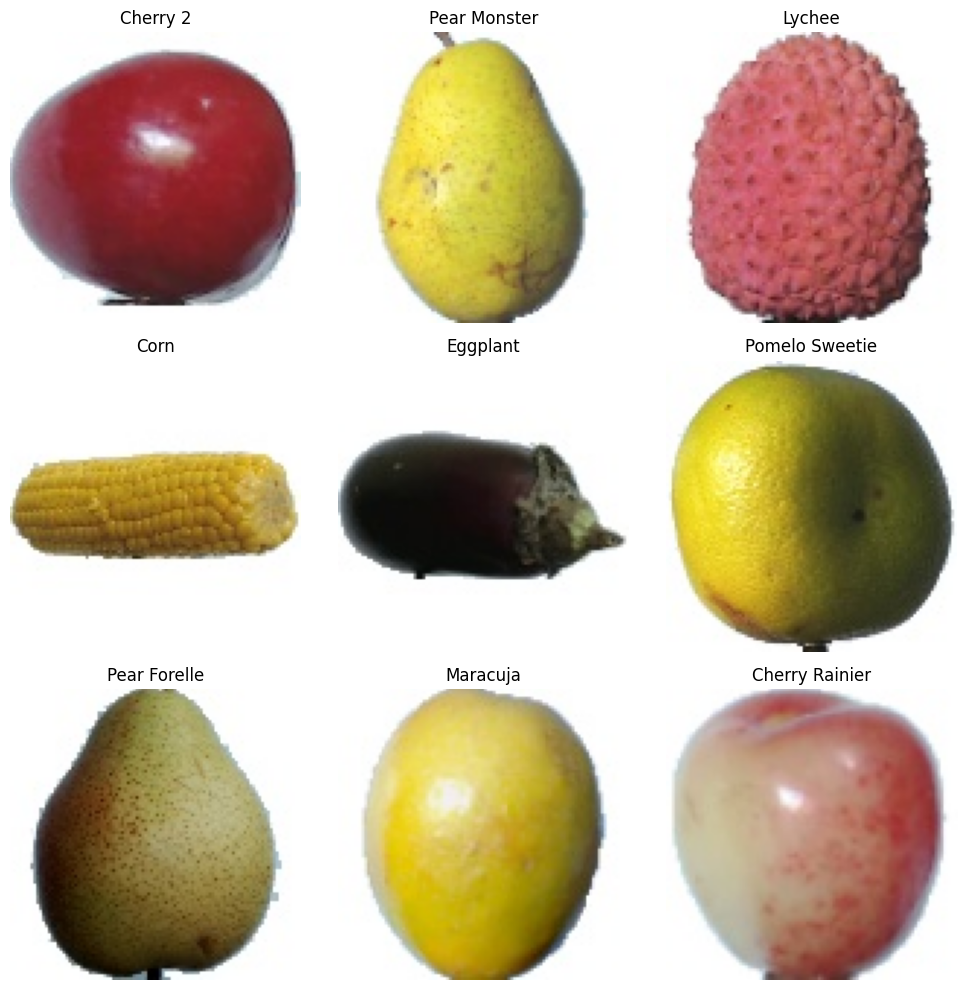

In [4]:
import matplotlib.image as mpimg
import random

root_path = 'Fruit-Image-Dataset'
splits = ['train', 'test']
all_images = []

for split in splits:
    split_path = os.path.join(root_path, split, split)
    for category in os.listdir(split_path):
        category_path = os.path.join(split_path, category)
        images = [f for f in os.listdir(category_path) if os.path.isfile(os.path.join(category_path, f))]
        all_images.extend([(os.path.join(category_path, img), category) for img in images])

# Number of images to display
num_images_to_show = 9

# Randomly sample images (avoid errors if fewer than needed)
sampled_images = random.sample(all_images, min(num_images_to_show, len(all_images)))

# Plot the sampled images
plt.figure(figsize=(10, 10))
for i, (img_path, category) in enumerate(sampled_images):
    img = mpimg.imread(img_path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(category)
    plt.axis('off')

plt.tight_layout()
plt.show()

Data Preprocessing:
- Resizing

- Grayscale conversion

- Noise reduction

- Histogram equalization

- Cropping

- Data augmentation (rotation, shift, flip, etc.)

In [5]:
from tqdm import tqdm

# Set input and output paths
original_root = '/content/Fruit-Image-Dataset'
splits = ['train/train', 'test/test']
output_root = '/content/preprocessed_augmented_dataset'
os.makedirs(output_root, exist_ok=True)

# ImageDataGenerator for augmentation
augmentor = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Preprocess and augment a single image
def preprocess_and_augment(image_path, augment_count=3):
    image = cv2.imread(image_path)
    if image is None:
        return []

    resized = cv2.resize(image, (256, 256))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    enhanced = cv2.equalizeHist(blurred)
    _, binary = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    denoised = cv2.fastNlMeansDenoising(binary, h=10)

    cropped_images = []
    contours, _ = cv2.findContours(denoised, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        cropped = resized[y:y+h, x:x+w]
        if cropped.size > 0:
            cropped_images.append(cropped)

    # Augment the first valid cropped image (if any)
    augmented_images = []
    if cropped_images:
        img_array = np.expand_dims(cv2.resize(cropped_images[0], (256, 256)), axis=0)
        img_array = img_array.astype(np.float32) / 255.0

        aug_iter = augmentor.flow(img_array, batch_size=1)
        for _ in range(augment_count):
            aug_img = next(aug_iter)[0]
            aug_img = (aug_img * 255).astype(np.uint8)
            augmented_images.append(aug_img)

    return cropped_images + augmented_images

# Walk through dataset and process
for split in splits:
    input_root = os.path.join(original_root, split)
    for category in tqdm(os.listdir(input_root), desc=f"Processing {split}"):
        category_path = os.path.join(input_root, category)
        if not os.path.isdir(category_path):
            continue

        output_category_path = os.path.join(output_root, split.replace('/', '_'), category)
        os.makedirs(output_category_path, exist_ok=True)

        for i, img_name in enumerate(os.listdir(category_path)):
            img_path = os.path.join(category_path, img_name)
            processed_images = preprocess_and_augment(img_path)

            for j, proc_img in enumerate(processed_images):
                save_path = os.path.join(output_category_path, f"{os.path.splitext(img_name)[0]}_{j}.jpg")
                cv2.imwrite(save_path, proc_img)

print("All images preprocessed and augmented.")
print("Saved to:", output_root)

Processing test/test: 100%|██████████| 131/131 [36:51<00:00, 16.88s/it]

All images preprocessed and augmented.
Saved to: /content/preprocessed_augmented_dataset


Sample the dataset to train/test set

In [18]:
import shutil
import random

def create_sample_dataset(original_dir, output_dir, samples_per_class=200):
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
    os.makedirs(output_dir, exist_ok=True)

    classes = [d for d in os.listdir(original_dir) if os.path.isdir(os.path.join(original_dir, d))]

    for class_name in classes:
        src_dir = os.path.join(original_dir, class_name)
        dest_dir = os.path.join(output_dir, class_name)
        os.makedirs(dest_dir, exist_ok=True)

        all_images = [f for f in os.listdir(src_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        sampled_images = random.sample(all_images, min(samples_per_class, len(all_images)))

        for img_name in sampled_images:
            shutil.copy(os.path.join(src_dir, img_name), os.path.join(dest_dir, img_name))

# Example usage:
create_sample_dataset('/content/Fruit-Image-Dataset/train/train', '/content/sample_dataset/train', samples_per_class=200)
create_sample_dataset('/content/Fruit-Image-Dataset/test/test', '/content/sample_dataset/test', samples_per_class=100)

In [32]:
# Counts the total number of images recursively inside each dataset folder

def count_images_in_folder(folder_path):
    total_images = 0
    for root, dirs, files in os.walk(folder_path):
        # Count only files with image extensions
        total_images += len([f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))])
    return total_images

original_train = '/content/Fruit-Image-Dataset/train/train'
original_test = '/content/Fruit-Image-Dataset/test/test'

preprocessed_train = '/content/preprocessed_augmented_dataset/train_train'
preprocessed_test = '/content/preprocessed_augmented_dataset/test_test'

sampled_train = '/content/sample_dataset/train'
sampled_test = '/content/sample_dataset/test'

print("Total images in ORIGINAL dataset:")
print("Train:", count_images_in_folder(original_train))
print("Test:", count_images_in_folder(original_test))
print()

print("Total images in PREPROCESSED dataset:")
print("Train:", count_images_in_folder(preprocessed_train))
print("Test:", count_images_in_folder(preprocessed_test))
print()

print("Total images in SAMPLED dataset:")
print("Train:", count_images_in_folder(sampled_train))
print("Test:", count_images_in_folder(sampled_test))


Total images in ORIGINAL dataset:
Train: 67692
Test: 22688

Total images in PREPROCESSED dataset:
Train: 806632
Test: 256530

Total images in SAMPLED dataset:
Train: 26200
Test: 13099


Split Train/Test set

In [19]:
# Parameters
image_size = 224
batch_size = 128

# Paths
train_dir = '/content/sample_dataset/train'
test_dir = '/content/sample_dataset/test'

# Data generators
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.20)  # 80% train, 20% val from train folder
test_datagen = ImageDataGenerator(rescale=1./255)

# Training data (80% of train folder)
train_dataset = train_datagen.flow_from_directory(
    train_dir,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=66
)

# Validation data (20% of train folder)
validation_dataset = train_datagen.flow_from_directory(
    train_dir,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=66
)

# Test data (from test folder, no subset)
test_dataset = test_datagen.flow_from_directory(
    test_dir,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Optional: check class mapping
print("Train class indices:", train_dataset.class_indices)
print("Validation class indices:", validation_dataset.class_indices)
print("Test class indices:", test_dataset.class_indices)

Found 20960 images belonging to 131 classes.
Found 5240 images belonging to 131 classes.
Found 13099 images belonging to 131 classes.
Train class indices: {'Apple Braeburn': 0, 'Apple Crimson Snow': 1, 'Apple Golden 1': 2, 'Apple Golden 2': 3, 'Apple Golden 3': 4, 'Apple Granny Smith': 5, 'Apple Pink Lady': 6, 'Apple Red 1': 7, 'Apple Red 2': 8, 'Apple Red 3': 9, 'Apple Red Delicious': 10, 'Apple Red Yellow 1': 11, 'Apple Red Yellow 2': 12, 'Apricot': 13, 'Avocado': 14, 'Avocado ripe': 15, 'Banana': 16, 'Banana Lady Finger': 17, 'Banana Red': 18, 'Beetroot': 19, 'Blueberry': 20, 'Cactus fruit': 21, 'Cantaloupe 1': 22, 'Cantaloupe 2': 23, 'Carambula': 24, 'Cauliflower': 25, 'Cherry 1': 26, 'Cherry 2': 27, 'Cherry Rainier': 28, 'Cherry Wax Black': 29, 'Cherry Wax Red': 30, 'Cherry Wax Yellow': 31, 'Chestnut': 32, 'Clementine': 33, 'Cocos': 34, 'Corn': 35, 'Corn Husk': 36, 'Cucumber Ripe': 37, 'Cucumber Ripe 2': 38, 'Dates': 39, 'Eggplant': 40, 'Fig': 41, 'Ginger Root': 42, 'Granadilla': 

In [20]:
image_size = 224
input_shape = (image_size,image_size,3)

num_classes = train_dataset.num_classes

model = Sequential()

model.add(Conv2D(filters=32,kernel_size=(3,3),input_shape = input_shape, activation= 'relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=64,kernel_size=(3,3),input_shape=input_shape, activation= 'relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=64,kernel_size=(3,3),input_shape=input_shape, activation= 'relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     5,537,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 131)            │        16,899 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,611,139 (21.40 MB)

 Trainable params: 5,611,139 (21.40 MB)

 Non-trainable params: 0 (0.00 B)

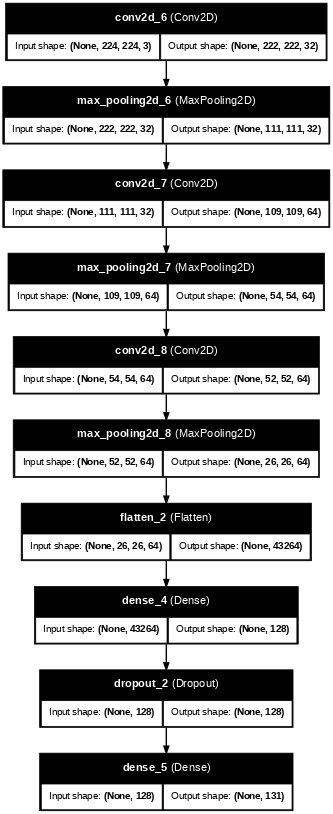

In [22]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True, dpi=50)

In [23]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=2e-4),
    metrics=['acc']
)

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

# Create the EarlyStopping callback
early_stop = EarlyStopping(
    monitor='val_loss',       # Also monitor 'val_accuracy' or 'val_acc'
    patience=3,               # Stop if no improvement after 3 epochs
    restore_best_weights=True  # Roll back to best weights
)

# Train the model with early stopping
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=validation_dataset,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1297s 8s/step - acc: 0.0343 - loss: 4.6861 - val_acc: 0.2256 - val_loss: 3.5420
Epoch 2/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1303s 8s/step - acc: 0.1907 - loss: 3.4586 - val_acc: 0.6252 - val_loss: 1.9768
Epoch 3/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1324s 8s/step - acc: 0.3990 - loss: 2.3531 - val_acc: 0.7490 - val_loss: 1.1650
Epoch 4/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1274s 8s/step - acc: 0.5665 - loss: 1.5984 - val_acc: 0.8124 - val_loss: 0.8142
Epoch 5/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1277s 8s/step - acc: 0.6640 - loss: 1.1781 - val_acc: 0.8567 - val_loss: 0.5779
Epoch 6/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1271s 8s/step - acc: 0.7381 - loss: 0.9087 - val_acc: 0.8676 - val_loss: 0.4811
Epoch 7/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1263s 8s/step - acc: 0.7886 - loss: 0.7079 - val_acc: 0.8752 - val_loss: 0.4305
Epoch 8/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 1281s 8s/step - acc: 0.8297 - loss: 0.5540 - val_acc: 0.8966 - val_loss: 0.3826
Epoch 9/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 

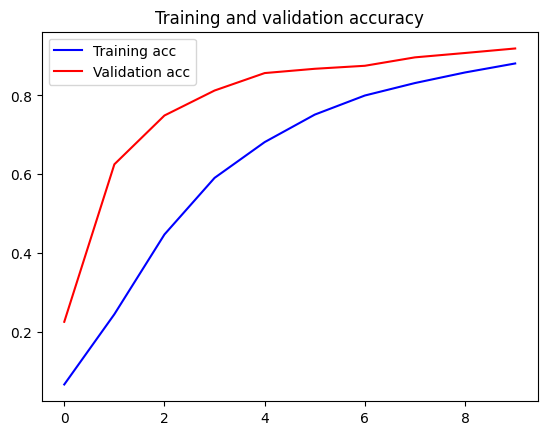

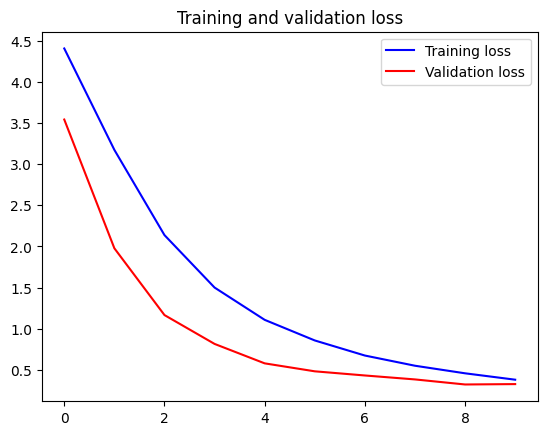

In [25]:
# Plot the accuracy and loss curves
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [26]:
scores = model.evaluate(validation_dataset, verbose=0)
print("test Accuracy: %.2f%%" % (scores[1]*100))


scores = model.evaluate(train_dataset, verbose=0)
print("train Accuracy: %.2f%%" % (scores[1]*100))

test Accuracy: 90.76%
train Accuracy: 99.70%


41/41 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step


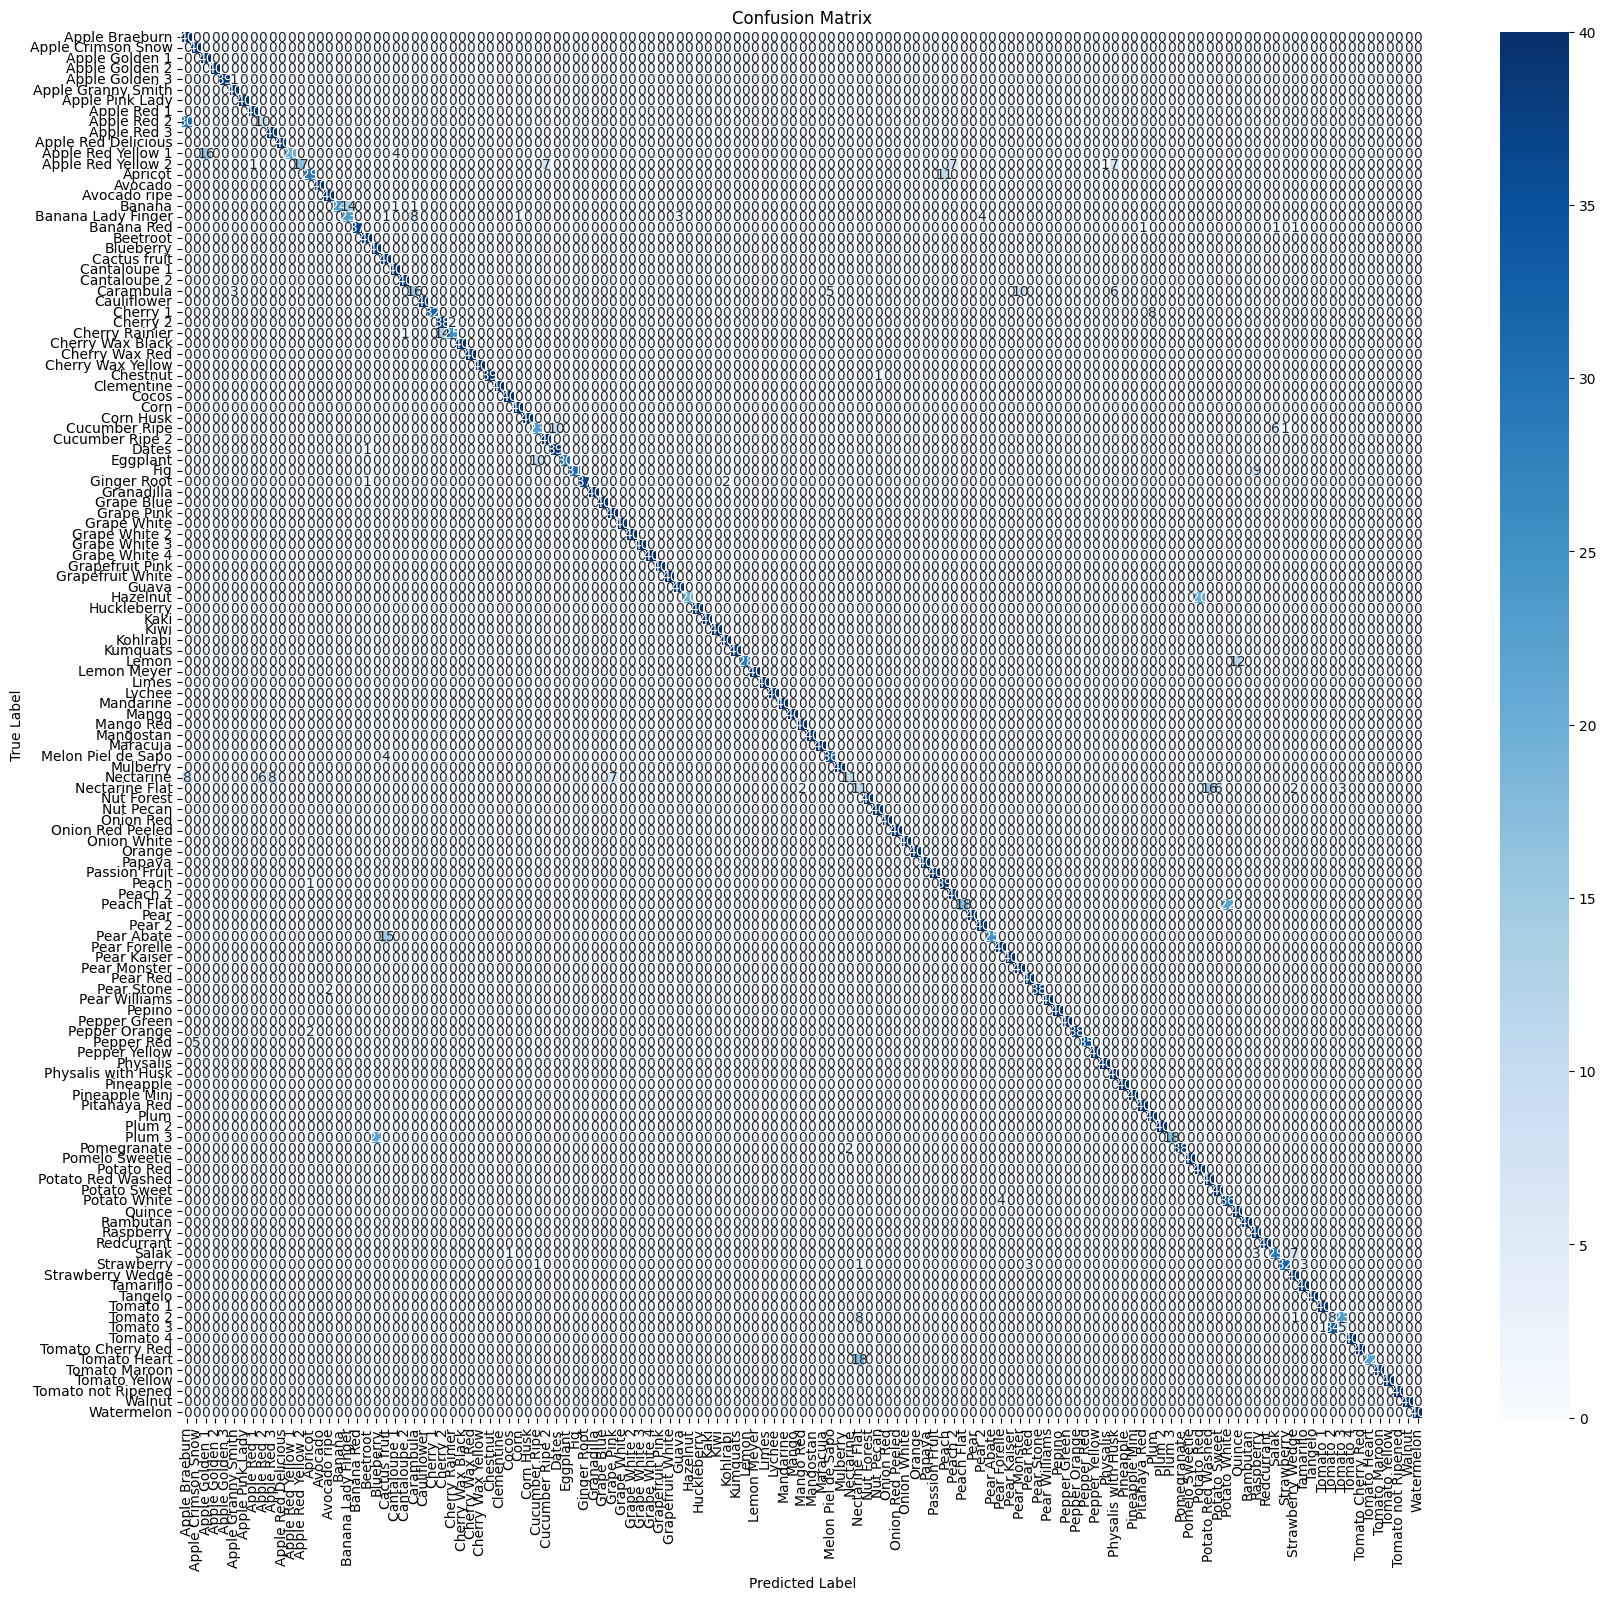

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get class names from the validation dataset
class_names = list(validation_dataset.class_indices.keys())

# Reset the validation dataset
validation_dataset.reset()

# Predict on the entire validation dataset at once
predictions = model.predict(validation_dataset, verbose=1)

# Get true labels from the dataset
true_labels = validation_dataset.classes  # Much faster! No need to loop
predicted_labels = np.argmax(predictions, axis=1)

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Create a heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

41/41 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step


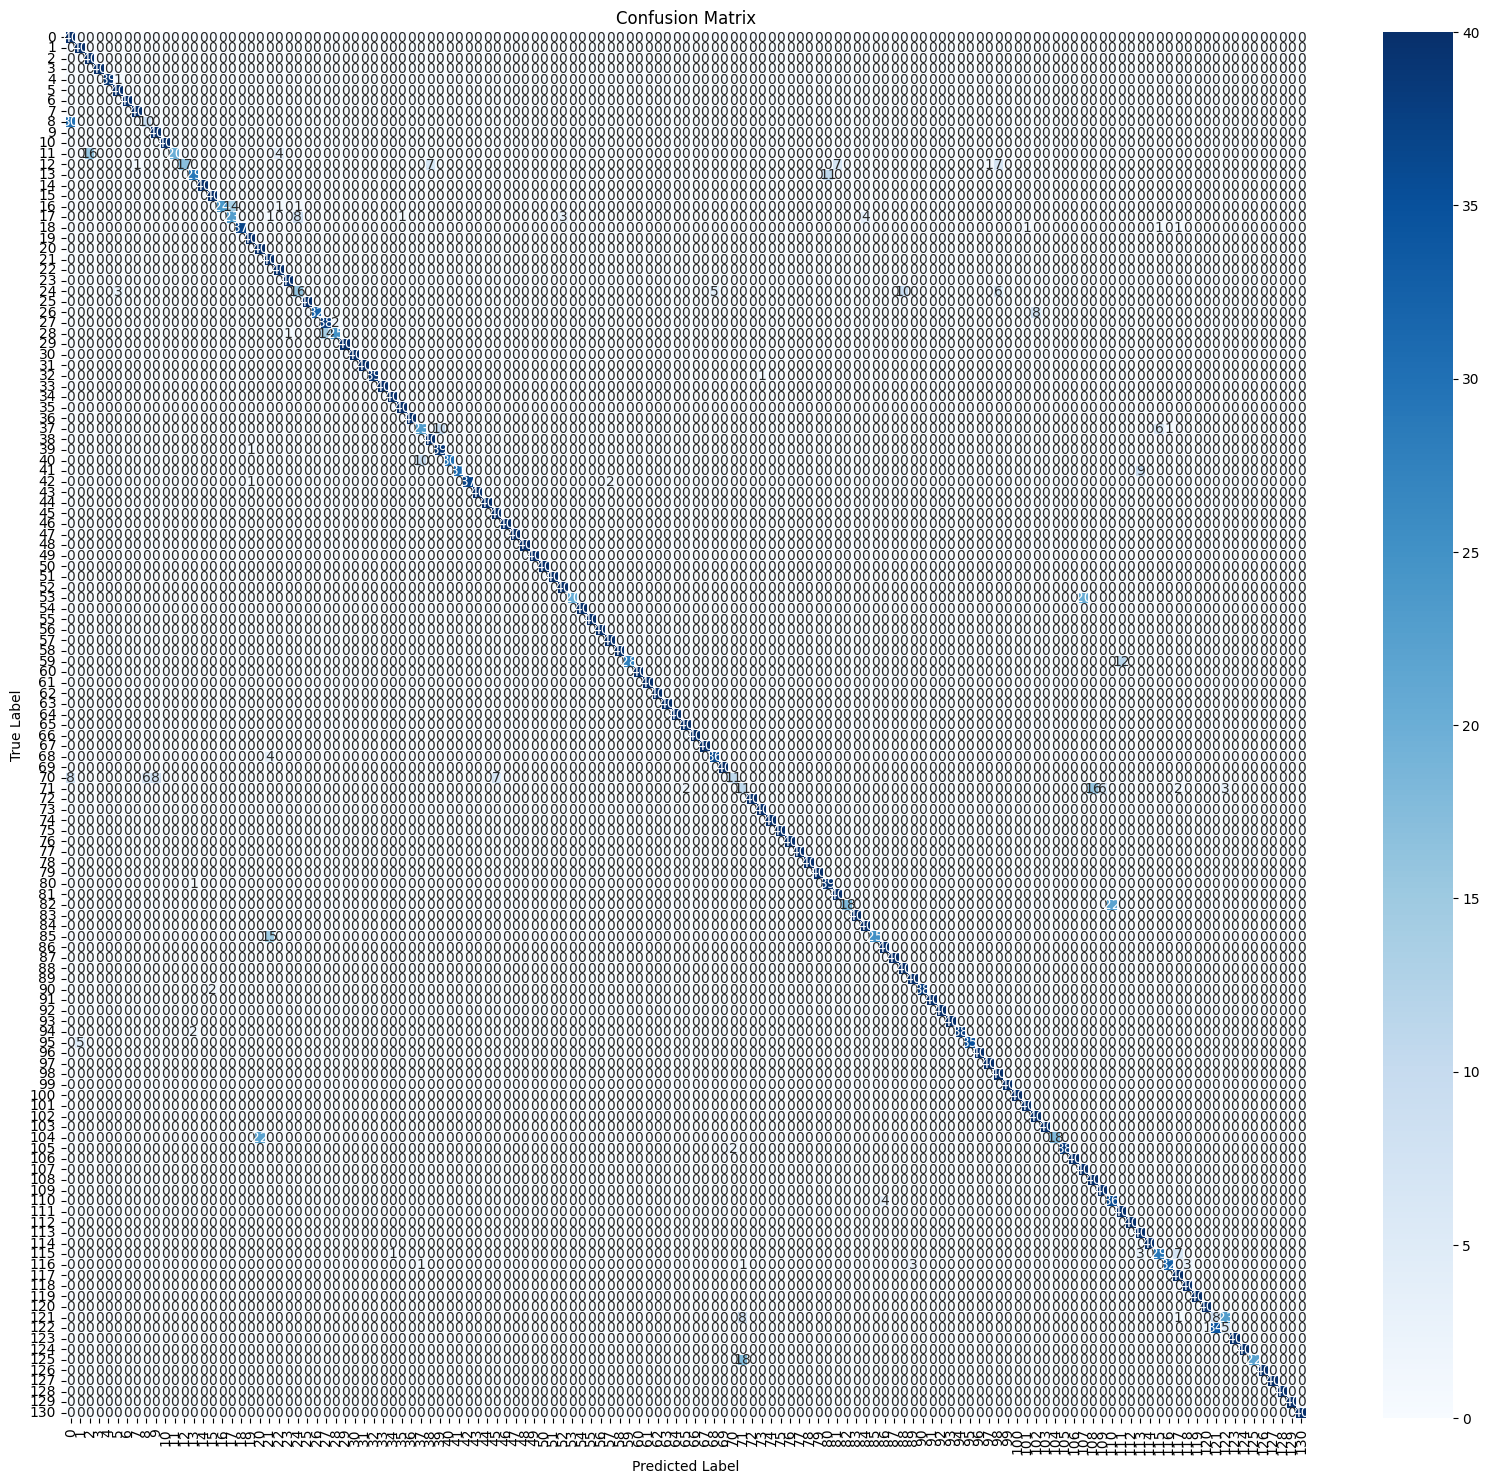

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Reset the validation dataset
validation_dataset.reset()

# Predict on the entire validation dataset at once
predictions = model.predict(validation_dataset, verbose=1)

# Get true labels
true_labels = validation_dataset.classes
predicted_labels = np.argmax(predictions, axis=1)

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Create class labels as numbers
num_classes = cm.shape[0]
class_names = list(range(num_classes))  # [0, 1, 2, ..., n-1]

# Create a heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

41/41 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step


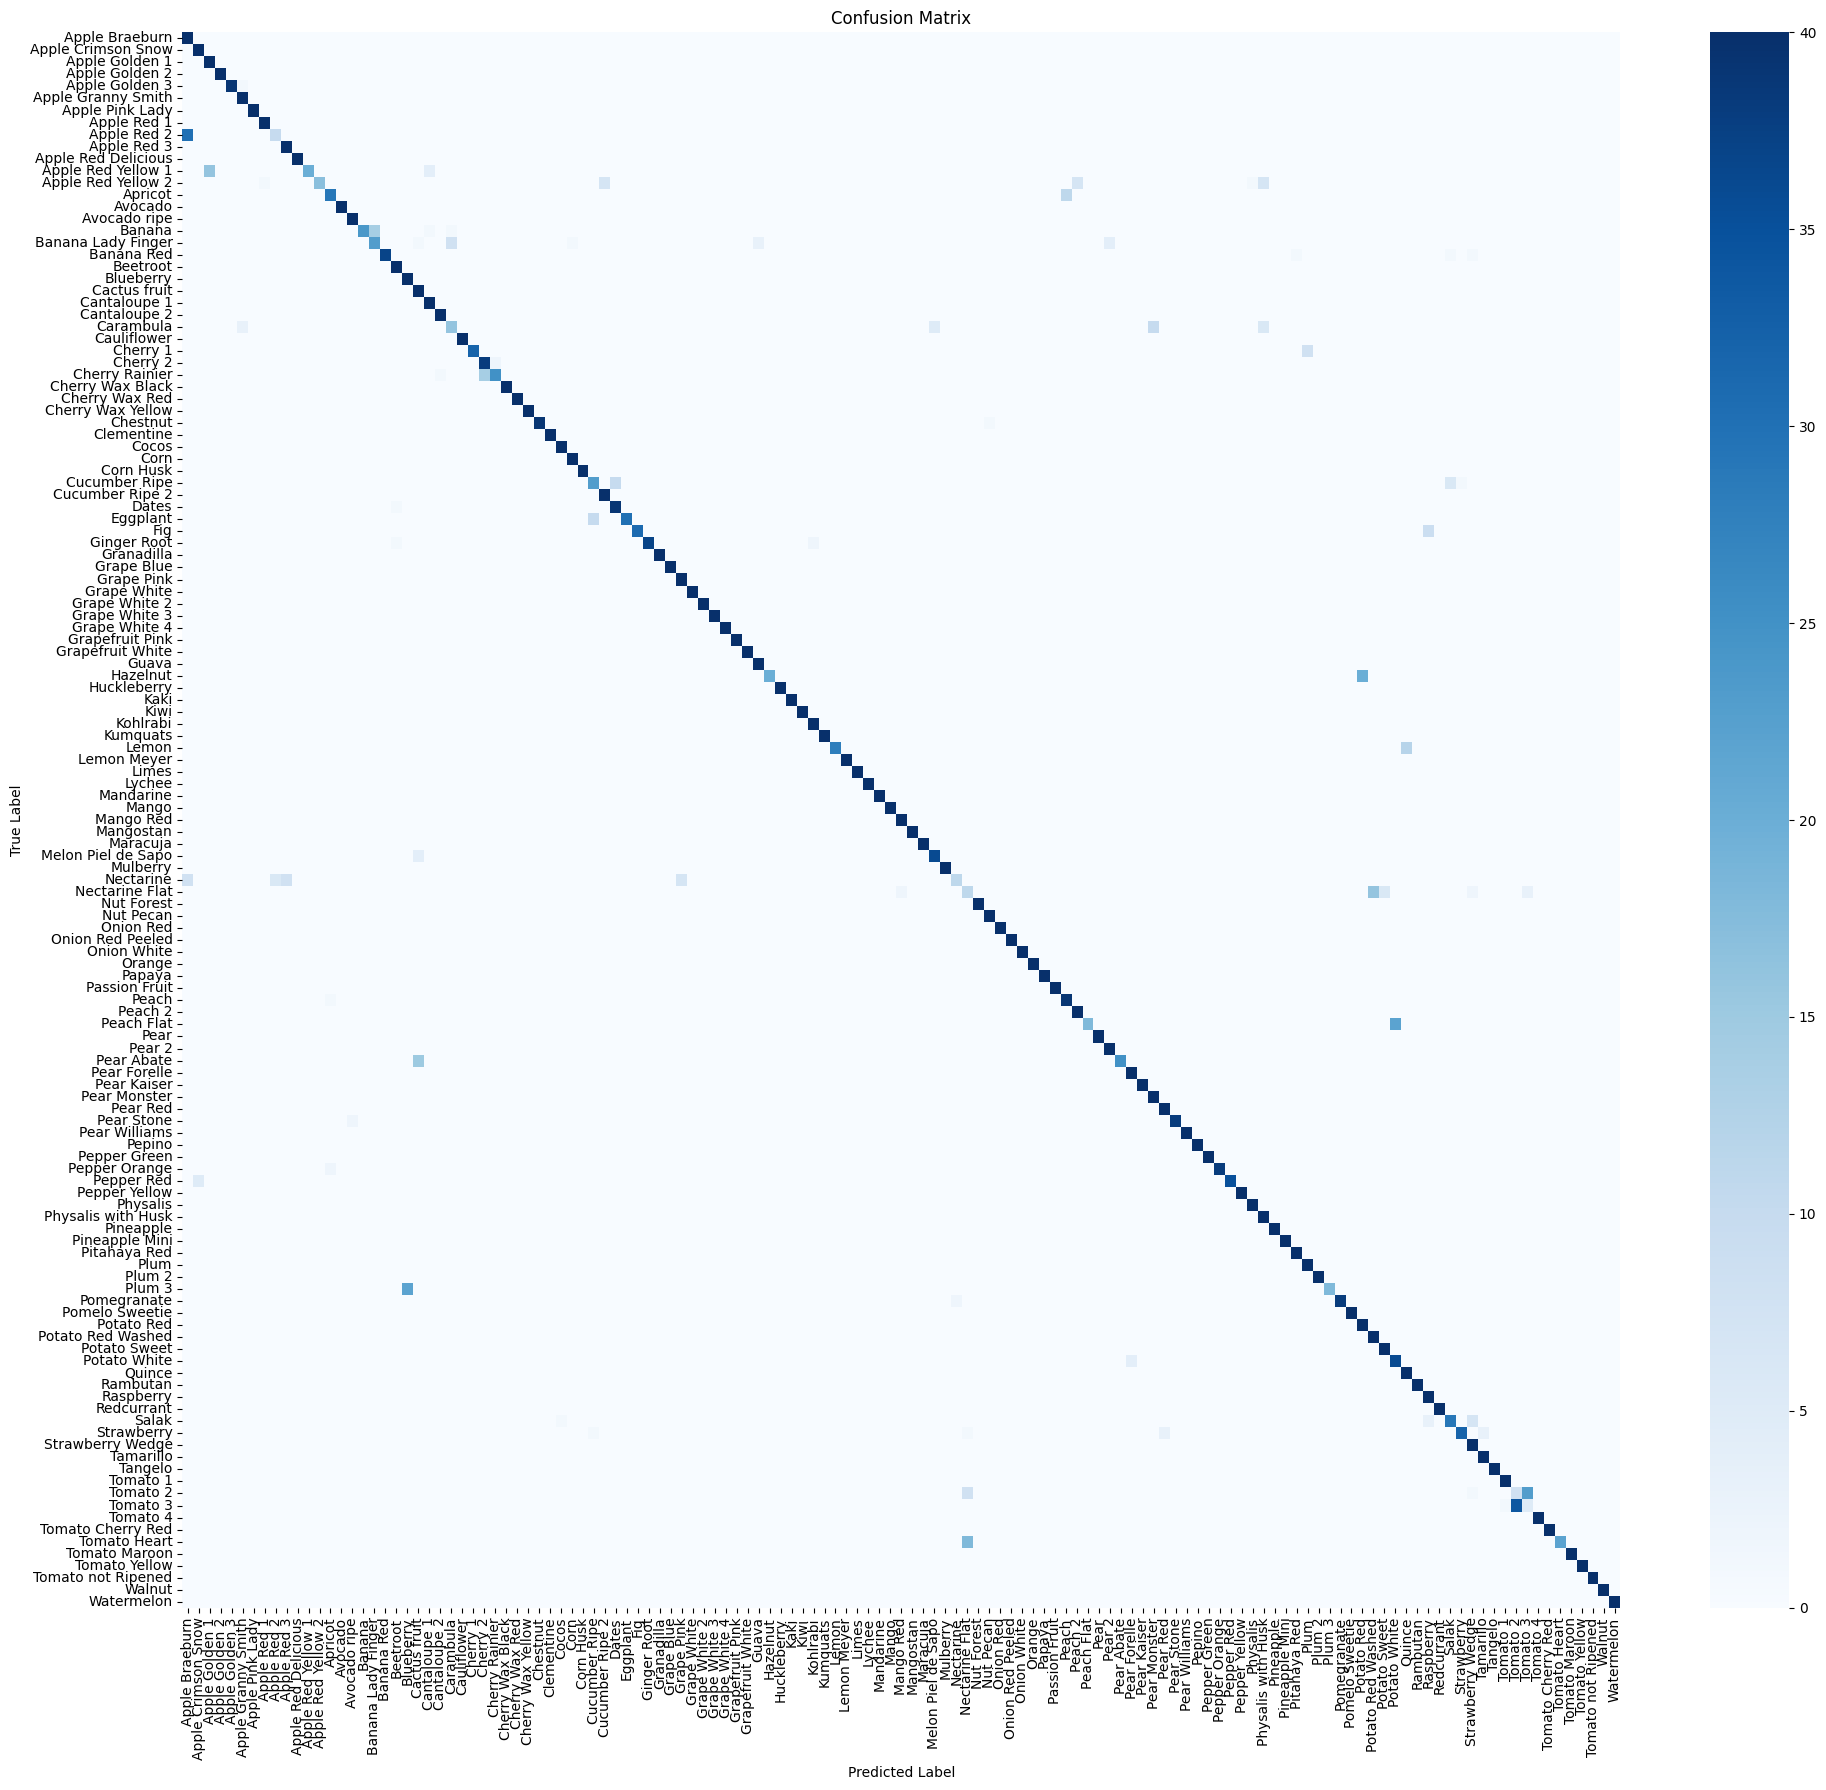

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Reset the validation dataset before prediction
validation_dataset.reset()

# Predict on the entire validation dataset
predictions = model.predict(validation_dataset, verbose=1)

# Get true and predicted labels
true_labels = validation_dataset.classes
predicted_labels = np.argmax(predictions, axis=1)

# Confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Get class names directly from the dataset
class_names = list(validation_dataset.class_indices.keys())

# Plot confusion matrix heatmap
plt.figure(figsize=(20, 18))  # Adjusted size for large number of classes
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

# Calculate F1 Score
f1 = f1_score(true_labels, predicted_labels, average='weighted')

# Calculate Precision
precision = precision_score(true_labels, predicted_labels, average='weighted')

# Calculate Recall
recall = recall_score(true_labels, predicted_labels, average='weighted')

# Calculate ROC-AUC Score
# For ROC-AUC, we need the full prediction probabilities and true labels as one-hot
# First check if there are more than two classes
if len(np.unique(true_labels)) > 2:
    # Multi-class AUC
    true_labels_one_hot = np.eye(len(np.unique(true_labels)))[true_labels]
    roc_auc = roc_auc_score(true_labels_one_hot, predictions, multi_class='ovr')
else:
    # Binary AUC
    roc_auc = roc_auc_score(true_labels, predictions[:,1])

# Print scores
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")


F1 Score: 0.9017
Precision: 0.9180
Recall: 0.9076
ROC-AUC Score: 0.9990


/tmp/ipython-input-3796274494.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)  # 10 colors for 10 classes


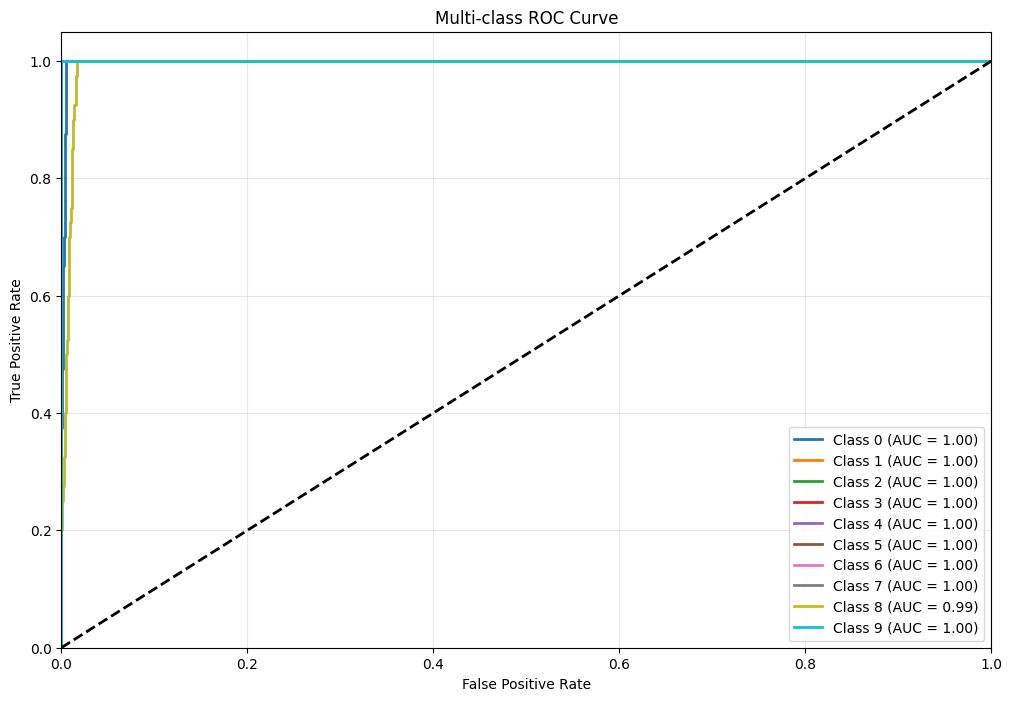

In [37]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Number of classes
n_classes = 10

# Binarize the true labels
true_labels_bin = label_binarize(true_labels, classes=list(range(n_classes)))

# Calculate FPR, TPR, and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(true_labels_bin[:, i], predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(12, 8))
colors = plt.cm.get_cmap('tab10', n_classes)  # 10 colors for 10 classes

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, color=colors(i),
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Reference:
- https://www.kaggle.com/datasets/ishandandekar/fruitimagedataset/data